In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import normalize

In [3]:
data = pd.read_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-04-2024.csv')
data.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,Number Instead of Word,Is WhoIs Registrar Available,Is SSL Certificate Retrievable,K-means Label,KMedoids Label,Hierarchical Label,DBSCAN Label,GMM Label,IPQS_Flag,Domain
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,0,1,0,0,0,2,0,0,0,1001minutesforukraine.com
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,0,1,0,0,0,2,0,0,0,1to1ukrainemuseums.org
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,0,0,1,0,0,2,0,0,0,1violettepourlukraine.fr
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,0,1,0,0,0,2,0,0,0,33lettersforukraine.com
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,0,0,0,0,2,3,0,2,1,4myukraine.com


In [4]:
df = data[data['DBSCAN Label'] != -1]
df.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,Number Instead of Word,Is WhoIs Registrar Available,Is SSL Certificate Retrievable,K-means Label,KMedoids Label,Hierarchical Label,DBSCAN Label,GMM Label,IPQS_Flag,Domain
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,0,1,0,0,0,2,0,0,0,1001minutesforukraine.com
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,0,1,0,0,0,2,0,0,0,1to1ukrainemuseums.org
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,0,0,1,0,0,2,0,0,0,1violettepourlukraine.fr
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,0,1,0,0,0,2,0,0,0,33lettersforukraine.com
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,0,0,0,0,2,3,0,2,1,4myukraine.com


In [5]:
print(len(data[data['DBSCAN Label'] == 1]))
print(len(data[data['DBSCAN Label'] == 0]))

print('-'*20)

print(len(data[data['IPQS_Flag'] == 1]))
print(len(data[data['IPQS_Flag'] == 0]))

print('-'*20)

print(len(data[(data['IPQS_Flag'] == 1) & (data['DBSCAN Label'] == 1)]))
print(len(data[(data['IPQS_Flag'] == 0) & (data['DBSCAN Label'] == 0)]))

363
1724
--------------------
510
1608
--------------------
259
1476


In [6]:
ipqs_ben_index = [i for i in range(len(list(df.IPQS_Flag))) if list(df.IPQS_Flag)[i]==0]
ipqs_mal_index = [i for i in range(len(list(df.IPQS_Flag))) if list(df.IPQS_Flag)[i]==1]

print(ipqs_ben_index)
print(ipqs_mal_index)
print(len(ipqs_ben_index))
print(len(ipqs_mal_index))

[0, 1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 57, 59, 61, 62, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 107, 108, 109, 110, 111, 113, 114, 115, 116, 117, 118, 119, 120, 121, 124, 125, 126, 127, 128, 129, 130, 132, 134, 135, 136, 138, 139, 140, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 154, 155, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 172, 174, 175, 176, 177, 178, 179, 182, 183, 184, 186, 187, 190, 192, 193, 194, 195, 197, 198, 199, 201, 202, 203, 204, 205, 207, 210, 211, 212, 213, 215, 216, 217, 218, 219, 220, 221, 224, 225, 226, 227, 228, 229, 230, 232, 234, 235, 236, 238, 239, 240, 241, 243, 244, 245, 247, 248, 249, 251, 252, 253, 254, 255, 256, 257, 258, 260, 261, 262, 264, 265, 266,

In [7]:
df = df.drop(columns=['IPQS_Flag'], axis=1)

In [8]:
print(len(data))
print(len(df))

2118
2087


In [9]:
clf_df = df.select_dtypes(include='number')
clf_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2117
Data columns (total 33 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Landing_Page_Size_In_KB                      2087 non-null   float64
 1   Same Landing Domain                          2087 non-null   int64  
 2   Has Bank Related Keywords                    2087 non-null   int64  
 3   Has Crypto Related Keywords                  2087 non-null   int64  
 4   Has Card Related Keywords                    2087 non-null   int64  
 5   Unique_Internal_Page_Link_Cnt                2087 non-null   int64  
 6   Unique_External_Page_Link_Cnt                2087 non-null   int64  
 7   Avg_External_Links_Len                       2087 non-null   float64
 8   Stdv_External_Links_Len                      2087 non-null   float64
 9   Ratio_Shortened_URL_And_External_Links       2087 non-null   float64
 10  Ratio

In [10]:
X = np.array(normalize(clf_df[clf_df.columns[:-6]]))
Y = np.array(clf_df['DBSCAN Label'])
set(Y)

{0, 1}

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42, shuffle=True)

In [12]:
clf = xgb.XGBClassifier(objective="binary:logistic", max_depth=5, random_state=42, n_estimators=100)

In [13]:
clf.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [14]:
predicted = clf.predict(x_test)
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       350
           1       1.00      0.99      0.99        68

    accuracy                           1.00       418
   macro avg       1.00      0.99      1.00       418
weighted avg       1.00      1.00      1.00       418



In [15]:
# Calculate accuracy
accuracy = accuracy_score(y_test, predicted)
print("Accuracy:", accuracy)

# Calculate precision
precision = precision_score(y_test, predicted)
print("Precision:", precision)

# Calculate recall
recall = recall_score(y_test, predicted)
print("Recall:", recall)

# Calculate F1 score
f1 = f1_score(y_test, predicted)
print("F1 score:", f1)

Accuracy: 0.9976076555023924
Precision: 1.0
Recall: 0.9852941176470589
F1 score: 0.9925925925925926


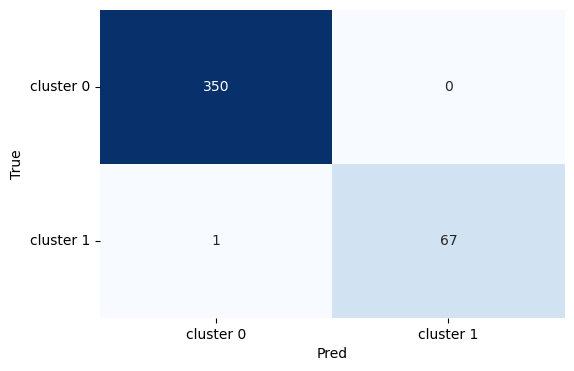

In [16]:
xgb_cm = metrics.confusion_matrix(y_test, predicted)
unique_classes = ['cluster 0', 'cluster 1']
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(xgb_cm, annot=True, fmt='d', ax=ax, cmap=plt.cm.Blues,
            cbar=False)
ax.set(xlabel="Pred", ylabel="True", xticklabels=unique_classes,
       yticklabels=unique_classes)
plt.yticks(rotation=0)
plt.show()

(2087, 27)


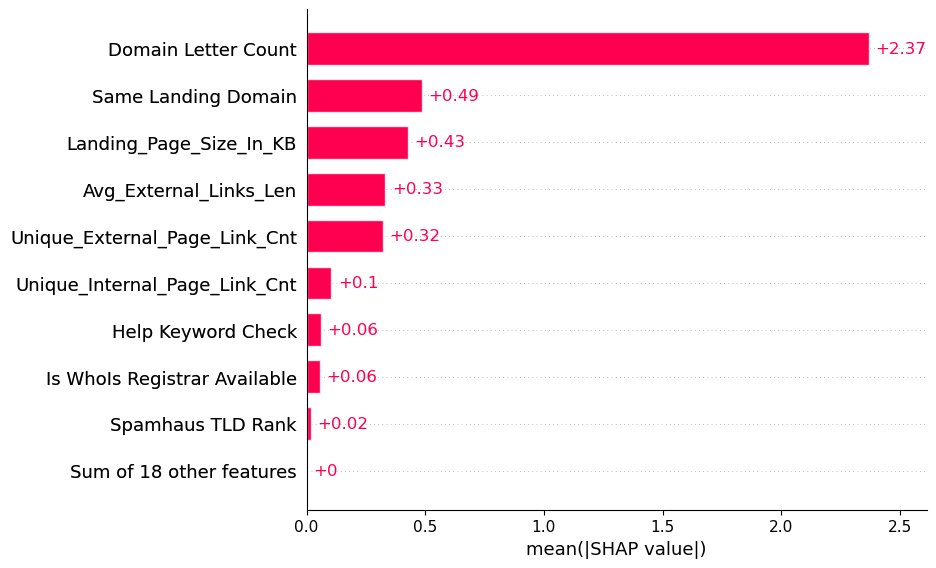

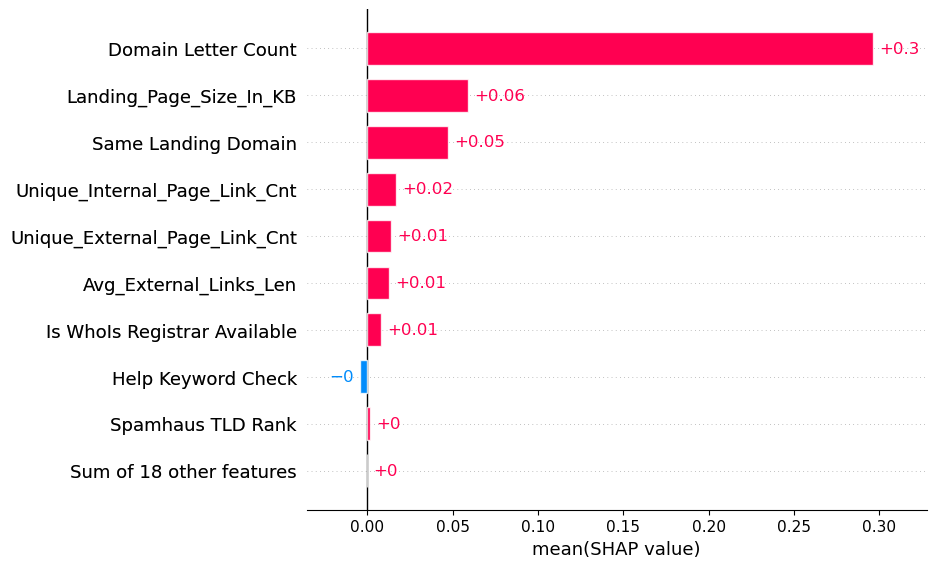

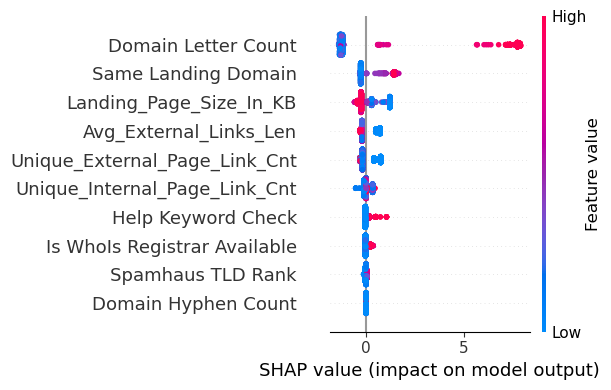

In [27]:
explainer = shap.TreeExplainer(clf,X)
shap_values = explainer(X,Y)
shap_values.feature_names = clf_df.columns[:-5]

print(shap_values.shape)

image_size = [6,4]

shap.plots.bar(shap_values, max_display=10)
shap.plots.bar(shap_values.mean(0), max_display=10)
shap.summary_plot(shap_values, max_display=10,plot_size=image_size)

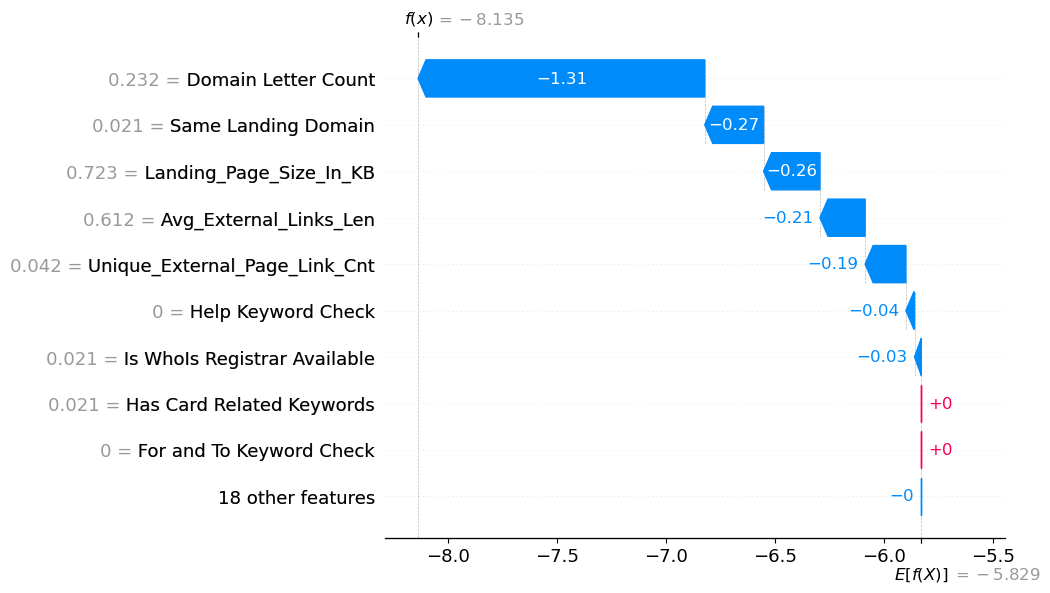

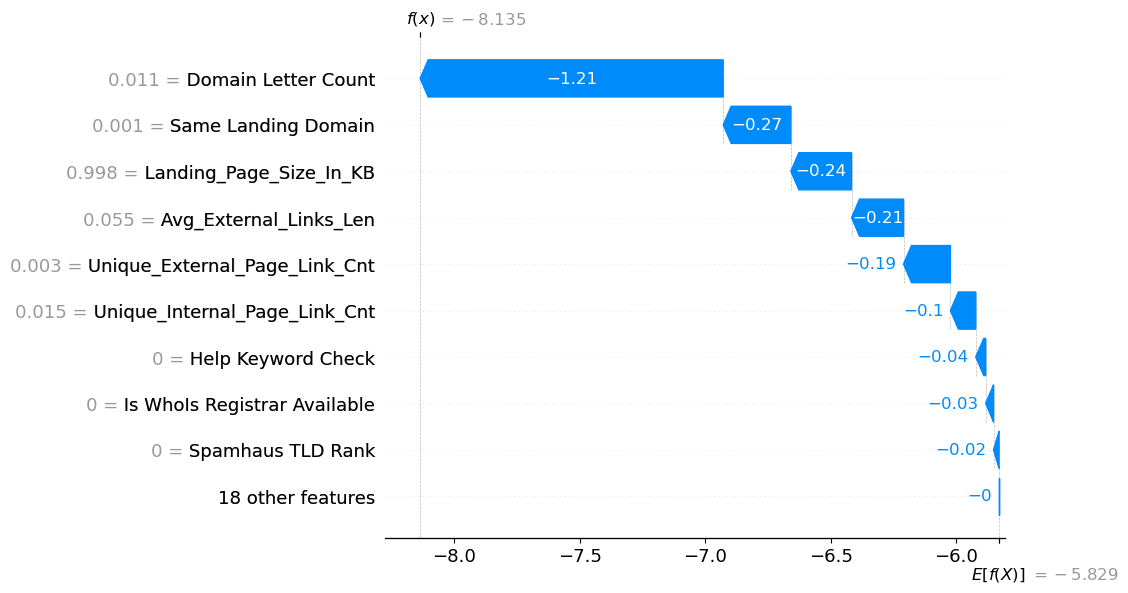

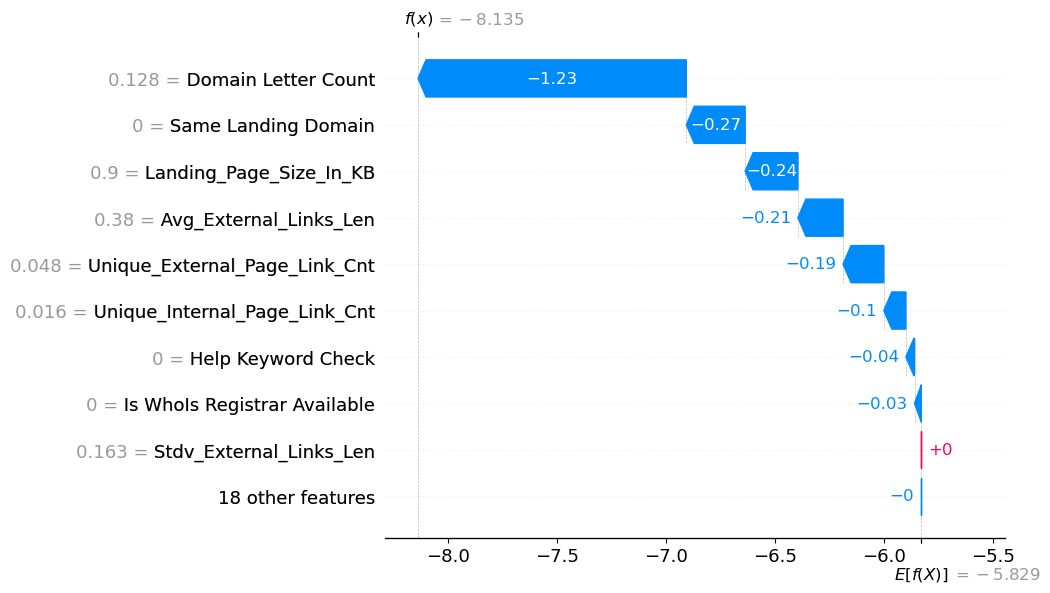

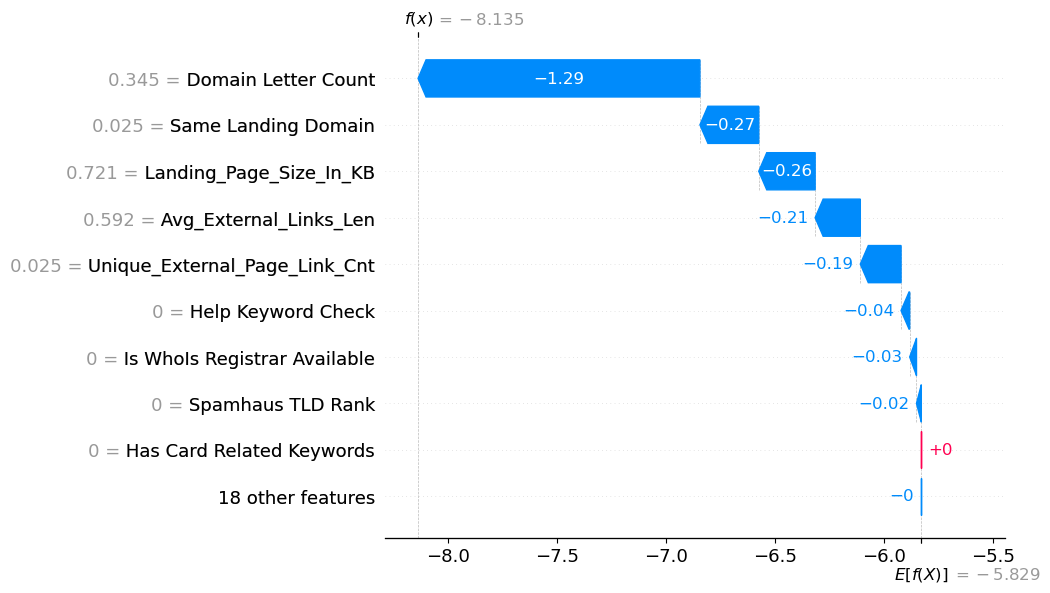

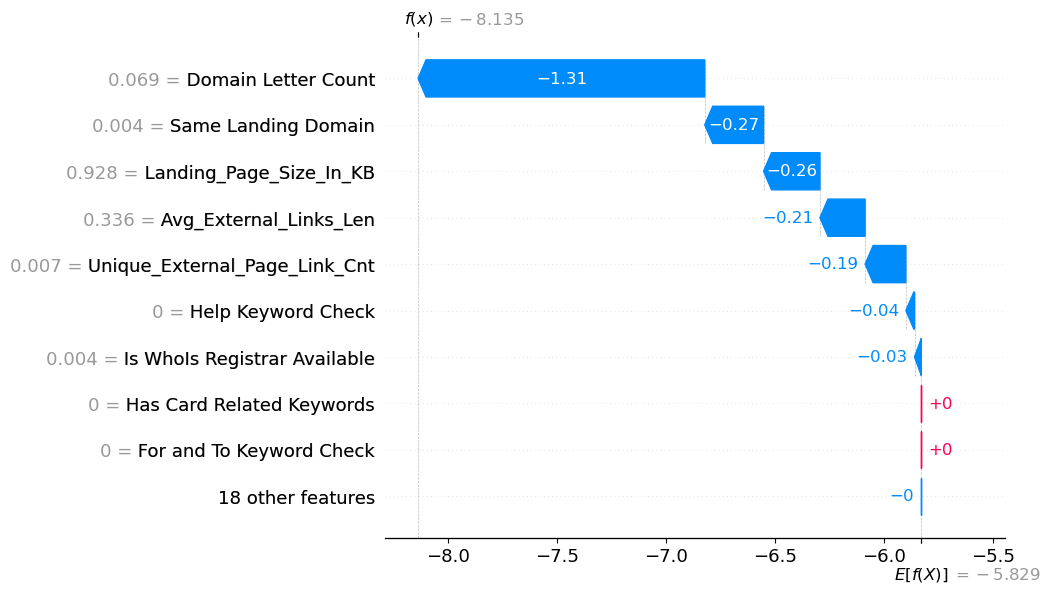

In [33]:
#local explanation for the benign class or cluster_0
cnt = 0
for i in range(1000):
    randi = np.random.randint(0,len(Y)-1)
    if Y[randi] == 0:
        cnt += 1
        plt.figure(figsize=image_size)
        shap.plots.waterfall(shap_values[randi], max_display=10)
        plt.show()
    if cnt>=5:
        break

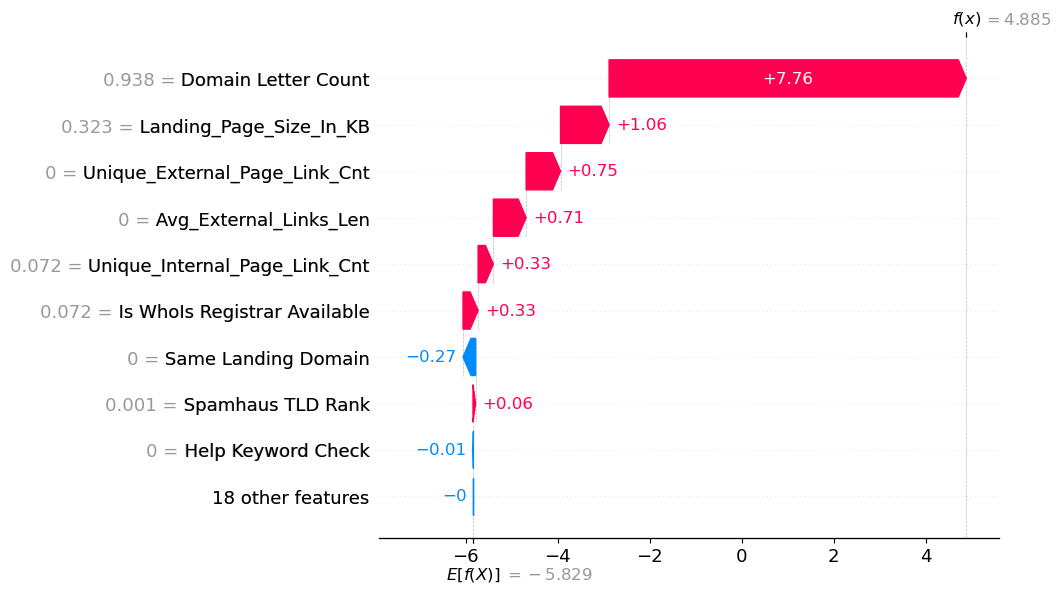

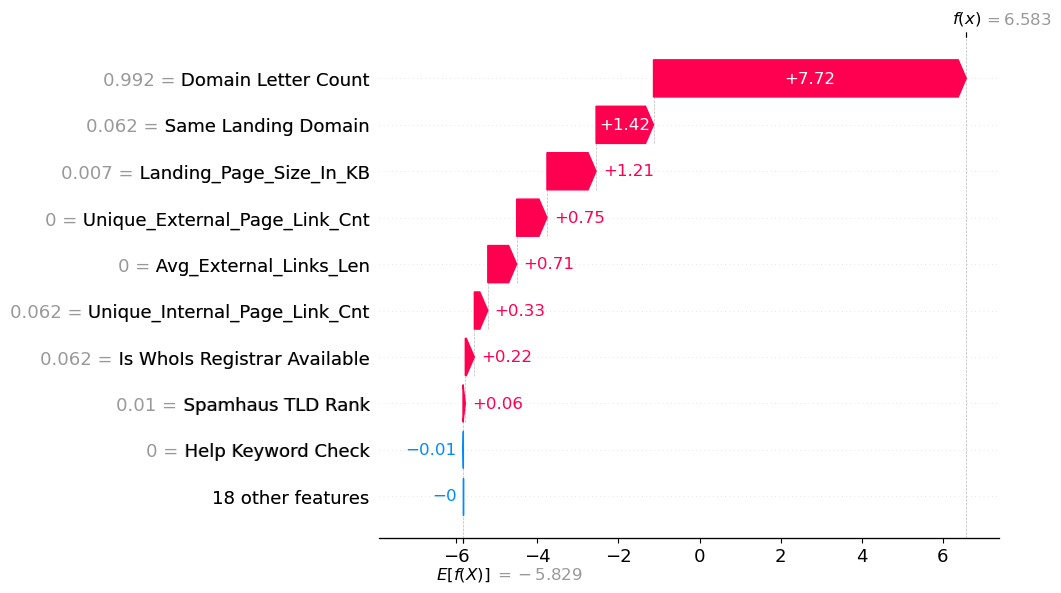

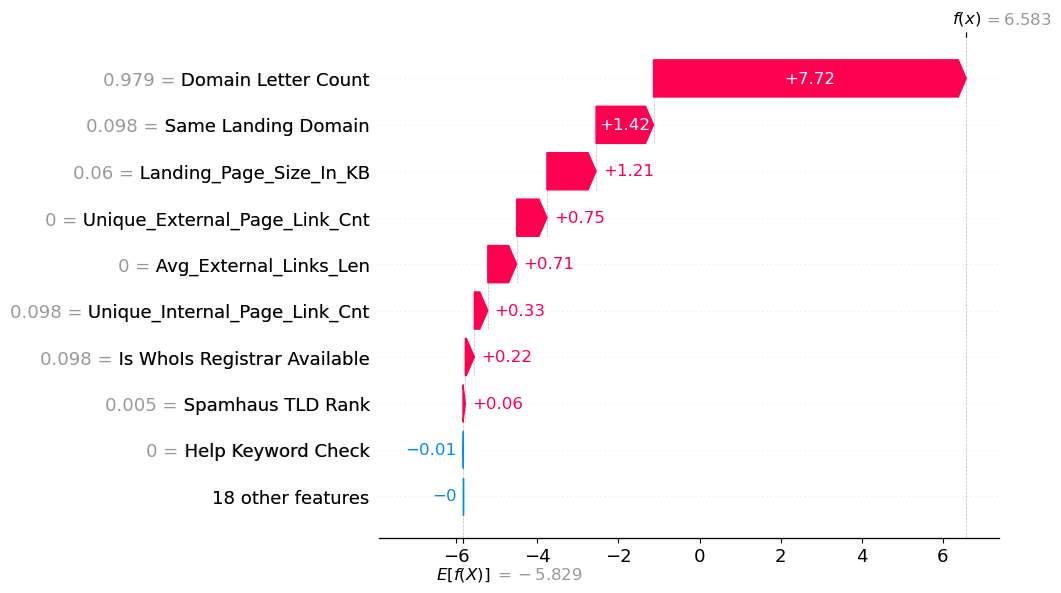

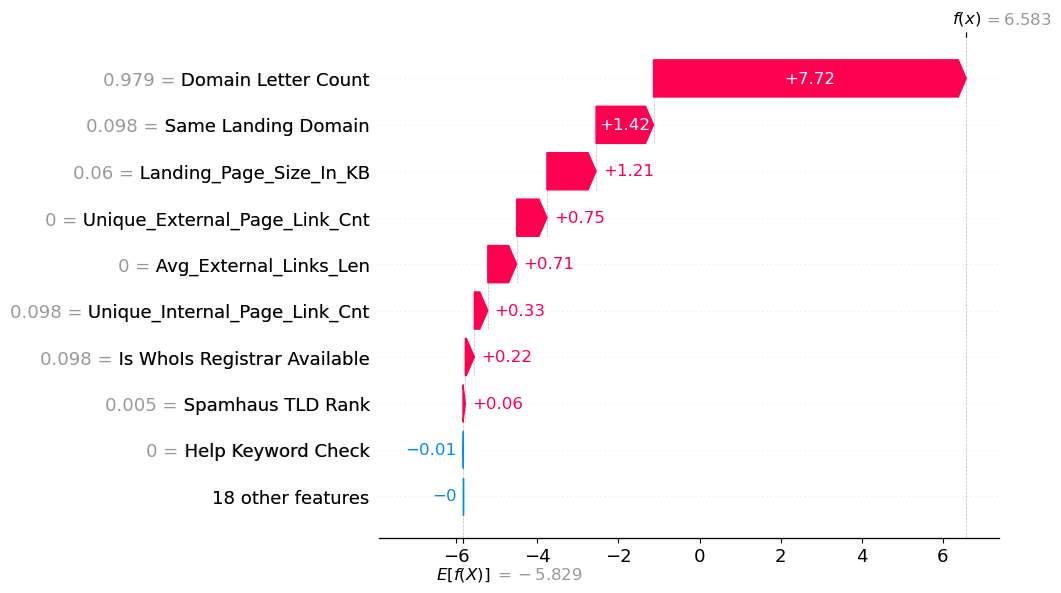

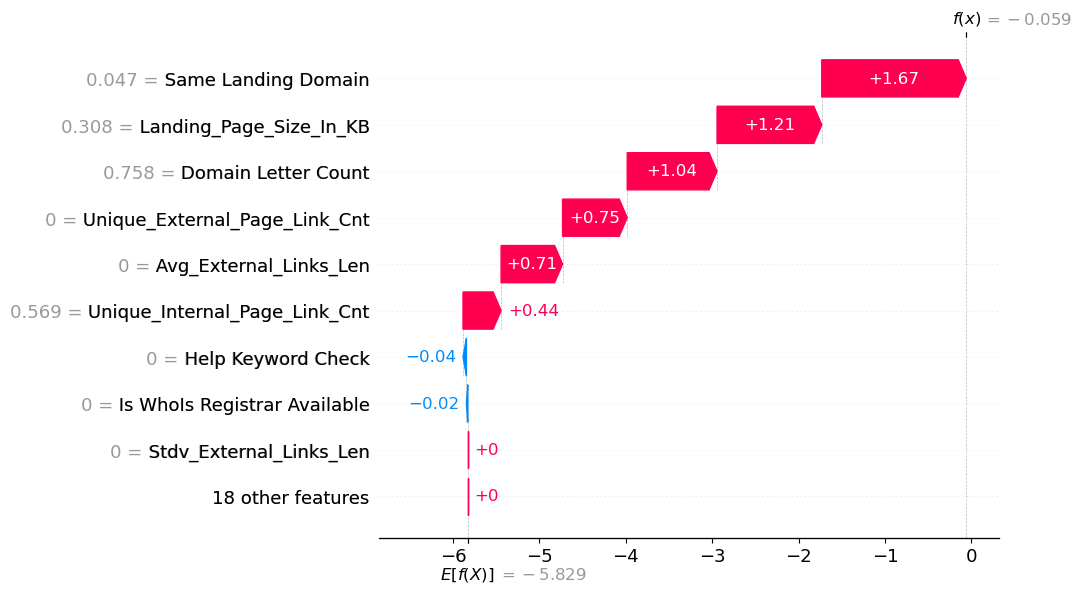

In [19]:
#local explanation for the malicious class or cluster_1
cnt = 0
for i in range(1000):
    randi = np.random.randint(0,len(Y)-1)
    if Y[randi] == 1:
        cnt += 1
        shap.plots.waterfall(shap_values[randi], max_display=10, show=True)
    if cnt>=5:
        break

In [20]:
print(list(Y[ipqs_ben_index]).count(0))
print(list(Y[ipqs_mal_index]).count(1))

1476
259


cluster label by our approach 0


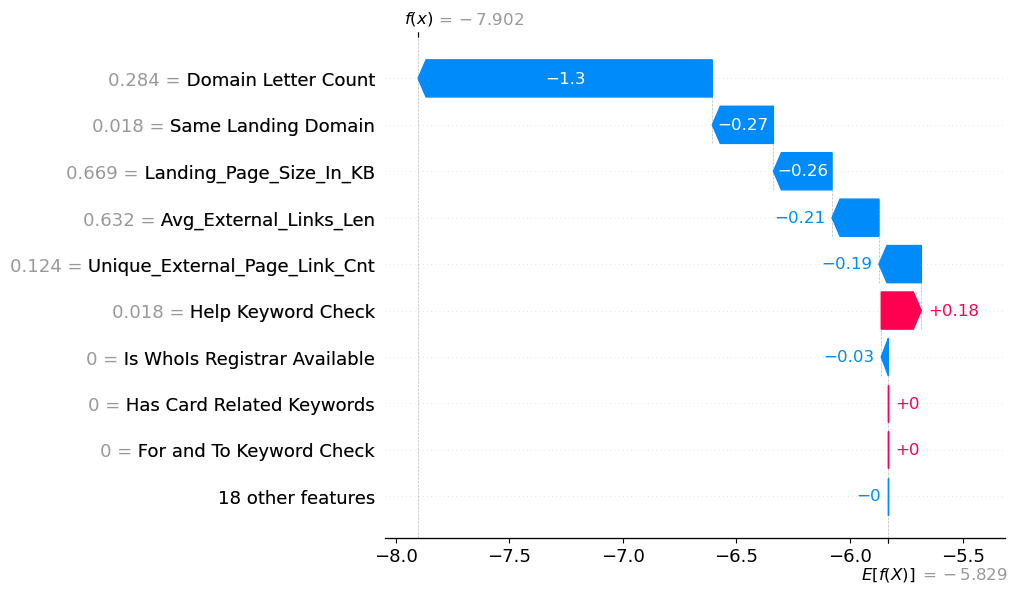

cluster label by our approach 0


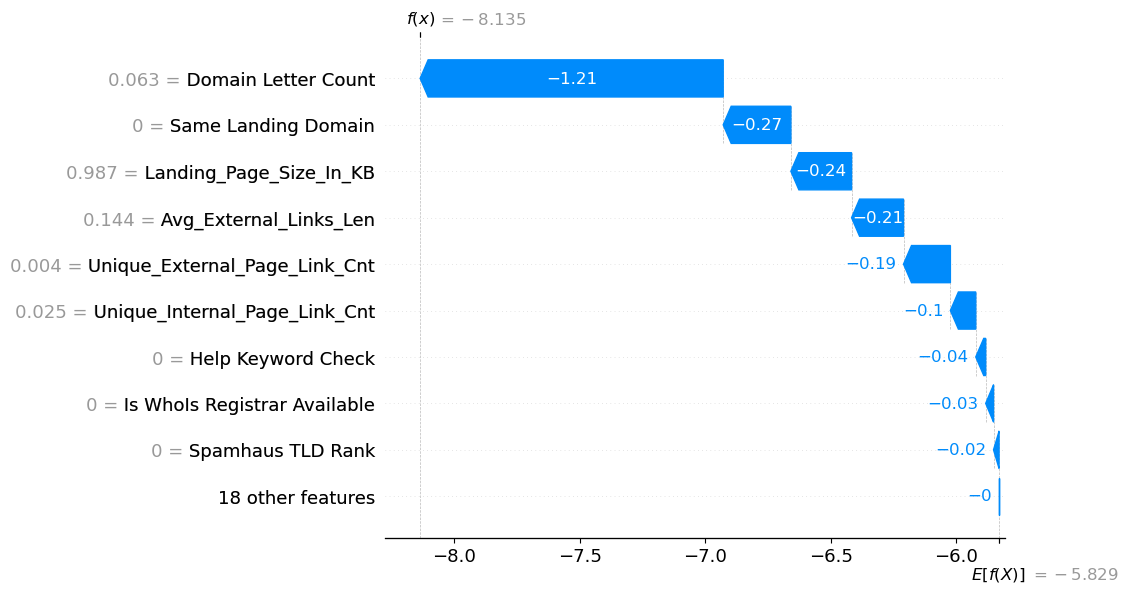

cluster label by our approach 0


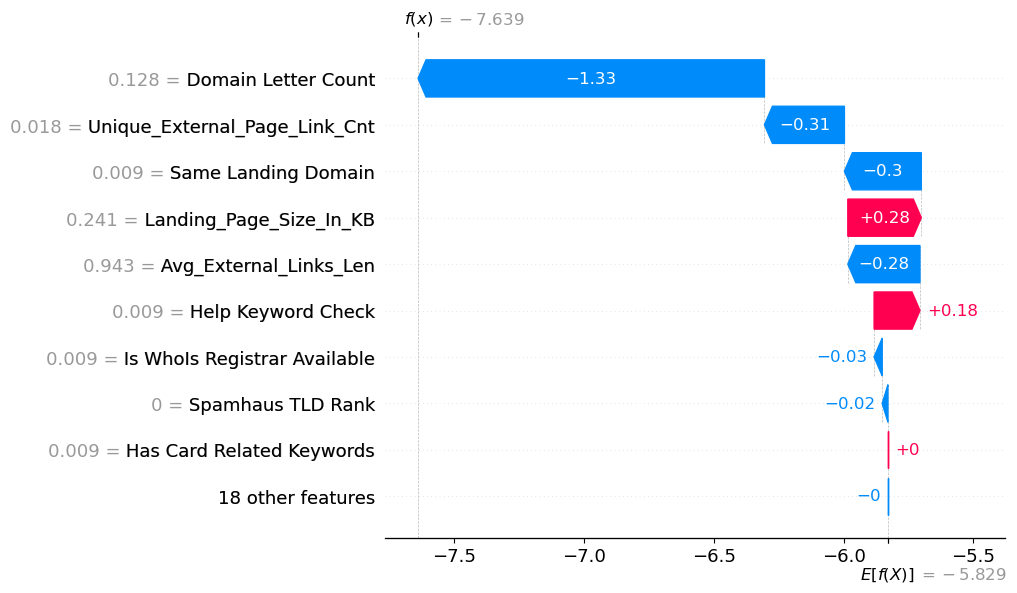

cluster label by our approach 0


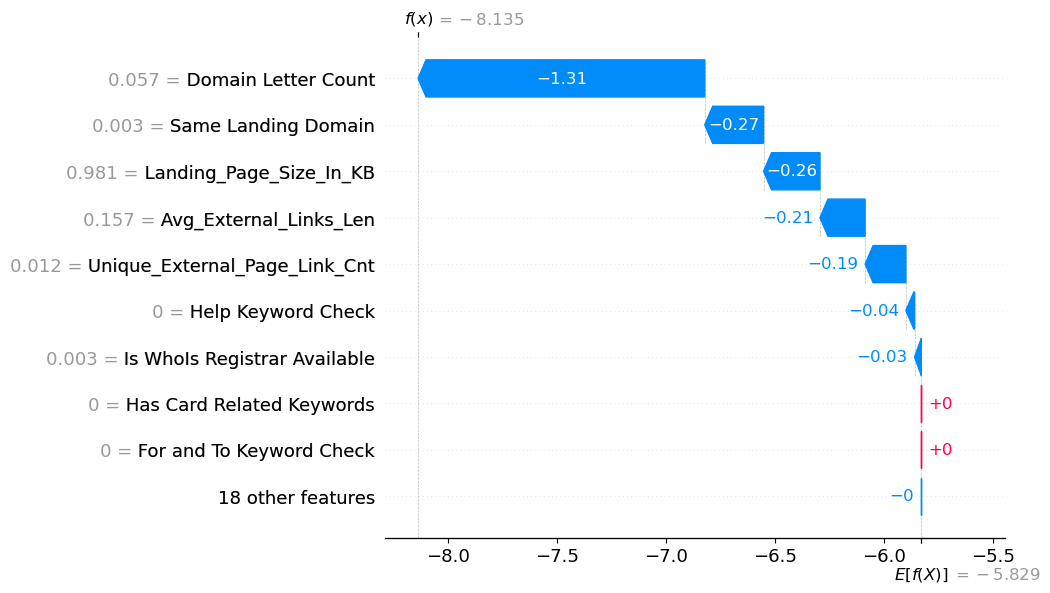

cluster label by our approach 0


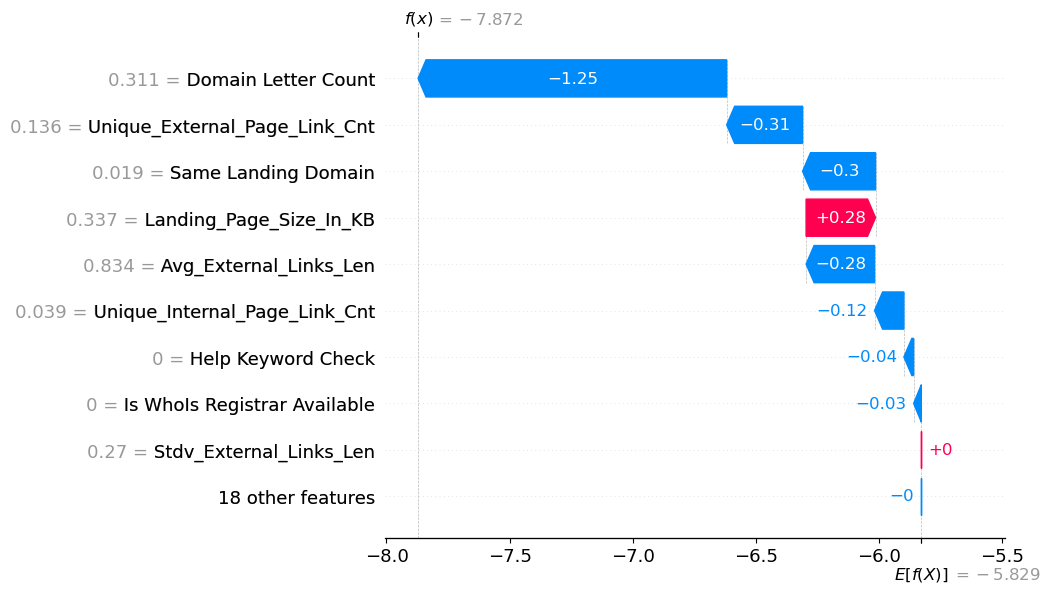

In [21]:
#local explanation for the ipqs benign class or suspicious flag false and risk score<75

for i in range(5):
    randi = random.choice(ipqs_ben_index)
    print('cluster label by our approach',Y[randi])
    shap.plots.waterfall(shap_values[randi], max_display=10, show=True)

cluster label by our approach 0


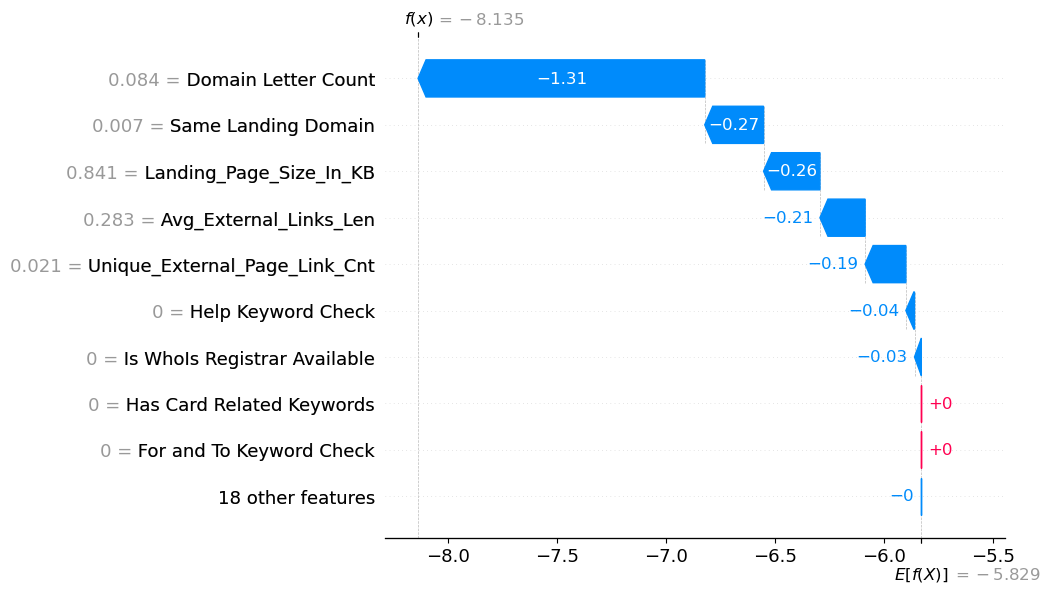

cluster label by our approach 0


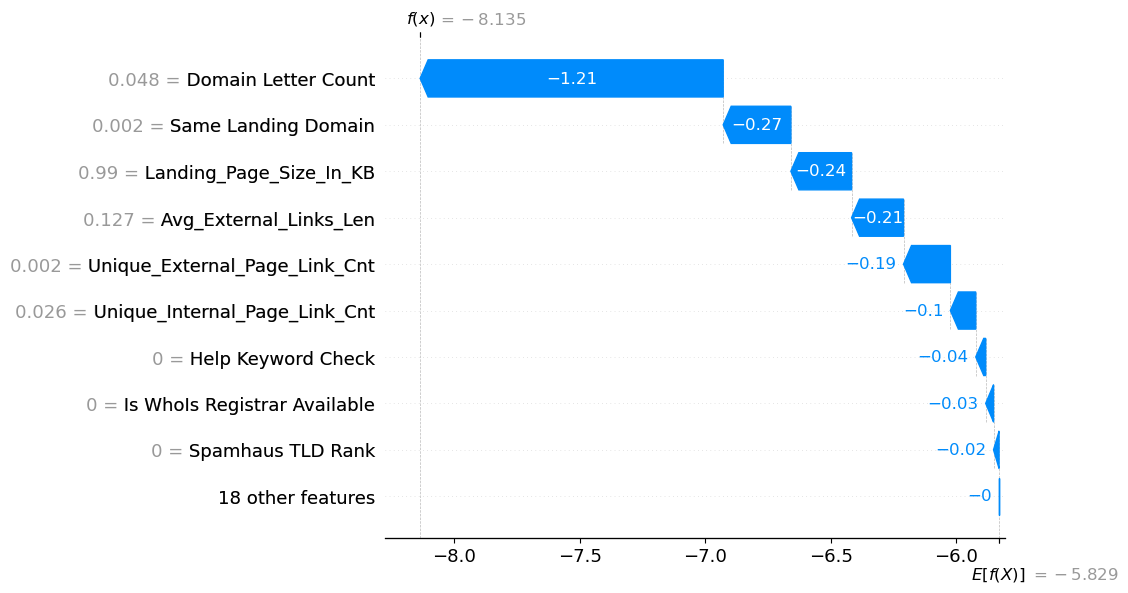

cluster label by our approach 1


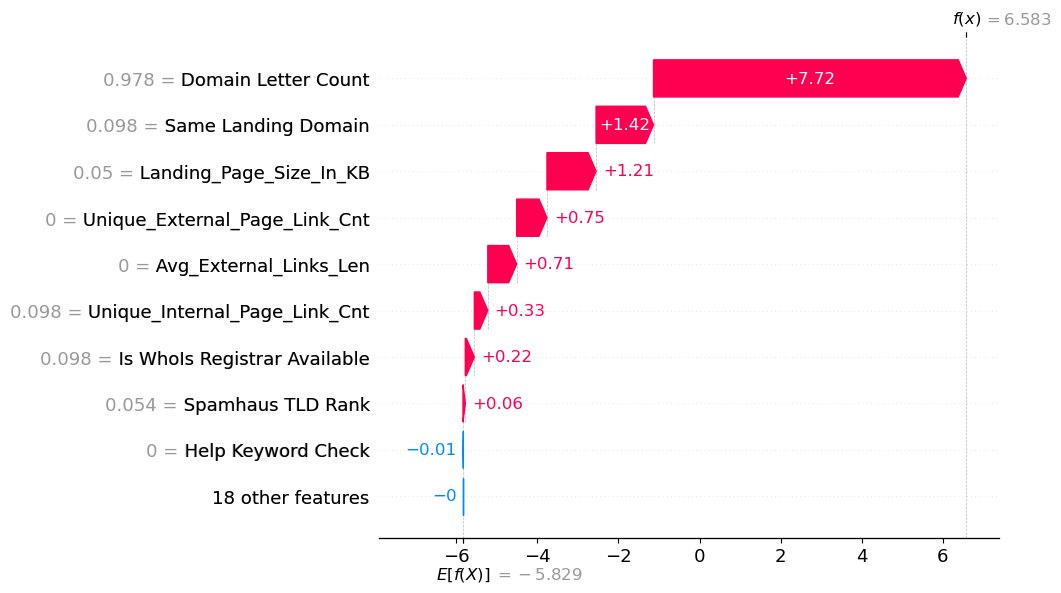

cluster label by our approach 1


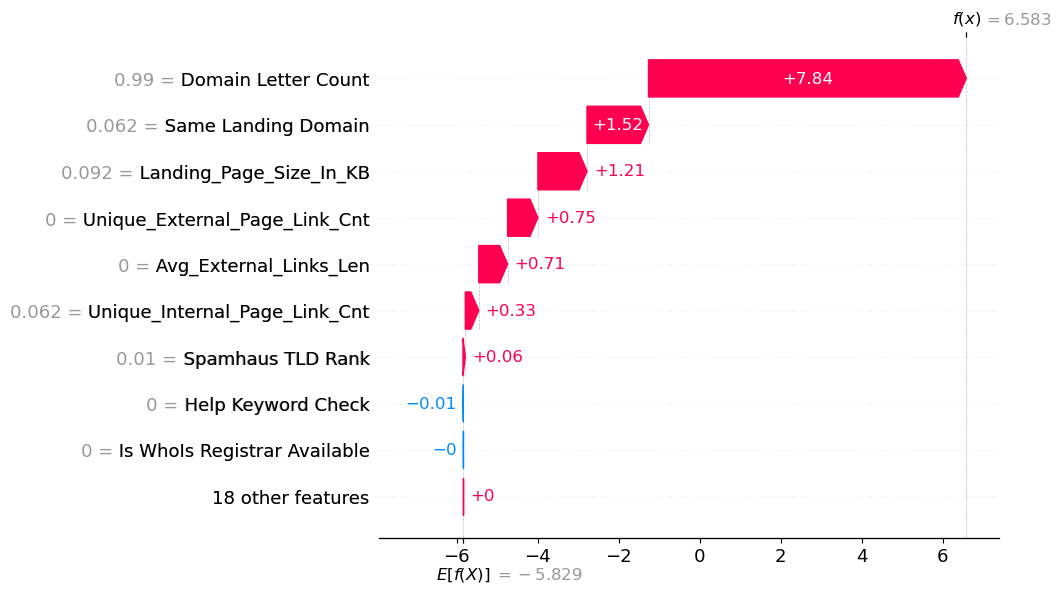

cluster label by our approach 1


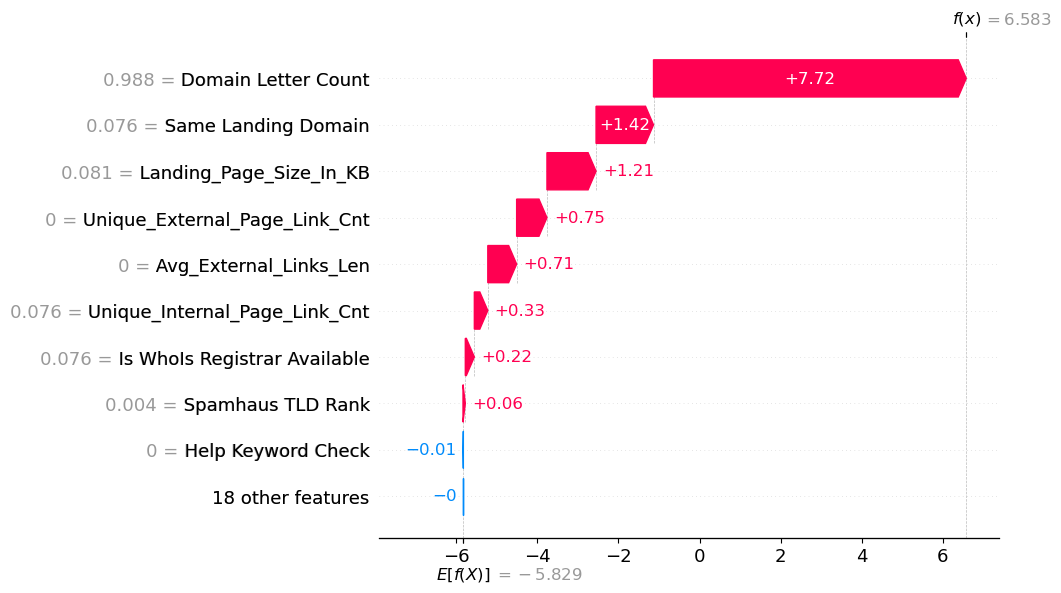

In [22]:
#local explanation for the ipqs malicious class or suspicious flag true and risk score>74

for i in range(5):
    randi = random.choice(ipqs_mal_index)
    print('cluster label by our approach',Y[randi])
    shap.plots.waterfall(shap_values[randi], max_display=10, show=True)